In [4]:
import torch
import os
from utilities import *
device = torch.device('cpu')
print(device)

cpu


In [13]:
# Parameters

ranges = [-1, 1]
n_train = 1000
n_test = 1000
steps = 200
grids = [3, 5, 10, 20, 50, 100]
k=3
lr=1
dimensions = [5, 10, 20, 50, 100, 200, 500, 1000]
seeds = [0, 1, 42]

In [15]:
def train_all_seeds(data):
    static_kan = {}
    dyn_kan = {}
    mlp = {}

    for seed in seeds:
        
        static_kan_results = {}
        dyn_kan_results = {}
        mlp_results = {}
        
        for d in dimensions:
            dataset_path = os.path.join("datasets", f'seed {seed}', f'{data}_dataset_dim{d}_seed{seed}.pt')
            if os.path.exists(dataset_path):
                dataset = torch.load(dataset_path, map_location='cpu')
            else:
                dataset = generate_dataset(d, data, seed, n_train, n_test, device=torch.device('cpu'), ranges=ranges)
            width = [d, 1, 1]
            kan_param = (width[0] * width[1] * (grids[0] + k + 3) + width[1]) + (width[1] * width[2] * (grids[0] + k + 3) + width[2])
            mlp_hidden_width = math.ceil((10*d+11)/(d+2)) - 1

            static_kan_results[d] = train_kan(width=width, dataset=dataset, static=True, seed=seed, steps=steps,grids=grids, lr=lr, k=k)
            dyn_kan_results[d] = train_kan(width=width, dataset=dataset, static=False, seed=seed, steps=steps, grids=grids, lr=lr, k=k)
            mlp_results[d] = train_mlp(width=[d, mlp_hidden_width, 1], dataset=dataset, seed=seed, steps=steps, lr=lr)
            mlp_param = mlp_results[d]['param_counts']
            print(f"Dimension {d}: KAN params: {kan_param}, MLP params: {mlp_param}")
        
        static_kan[seed] = static_kan_results
        dyn_kan[seed] = dyn_kan_results
        mlp[seed] = mlp_results
    
        output_dir = os.path.join("3-results", f'{steps}-epochs-seed-{seed}')
        os.makedirs(output_dir, exist_ok=True)
        torch.save(static_kan, os.path.join(output_dir, f'static_kan_{data}.pt'))
        torch.save(dyn_kan, os.path.join(output_dir, f'dyn_kan_{data}.pt'))
        torch.save(mlp, os.path.join(output_dir, f'mlp_{data}.pt'))
    return static_kan, dyn_kan, mlp


In [ ]:
static_kan_A, dyn_kan_A, mlp_A = train_all_seeds('A')

In [16]:
static_kan_B, dyn_kan_B, mlp_B = train_all_seeds('B')

Grid=3:   0%|          | 0/200 [00:00<?, ?it/s]

| train_loss: 1.25e-02 | test_loss: 1.40e-02 | reg: 3.04e+01 | : 100%|█| 200/200 [00:08<00:00, 23.80


Dimension 5: KAN params: 56, MLP params: 57


| train_loss: 5.29e-02 | test_loss: 6.77e-02 | reg: 5.04e+01 | : 100%|█| 200/200 [00:08<00:00, 22.98


Dimension 10: KAN params: 101, MLP params: 109


...

Dimension 200: KAN params: 1811, MLP params: 1819


| train_loss: 1.09e-07 | test_loss: 1.98e-01 | reg: 3.52e+02 | : 100%|█| 200/200 [00:16<00:00, 12.17


Dimension 500: KAN params: 4511, MLP params: 4519


| train_loss: 2.41e-08 | test_loss: 2.04e-01 | reg: 2.16e+02 | : 100%|█| 200/200 [00:25<00:00,  7.77


Dimension 1000: KAN params: 9011, MLP params: 9019


In [19]:
static_kan_C, dyn_kan_C, mlp_C = train_all_seeds('C')

Grid=3:   0%|          | 0/200 [00:00<?, ?it/s]

| train_loss: 3.17e-05 | test_loss: 3.50e-05 | reg: 2.49e+01 | : 100%|█| 200/200 [00:19<00:00, 10.21


Dimension 5: KAN params: 56, MLP params: 57


| train_loss: 1.65e-05 | test_loss: 1.85e-05 | reg: 3.81e+01 | : 100%|█| 200/200 [00:16<00:00, 12.23


Dimension 10: KAN params: 101, MLP params: 109


...

Dimension 200: KAN params: 1811, MLP params: 1819


| train_loss: 9.94e-08 | test_loss: 8.64e-02 | reg: 2.03e+02 | : 100%|█| 200/200 [00:21<00:00,  9.52


Dimension 500: KAN params: 4511, MLP params: 4519


| train_loss: 6.72e-08 | test_loss: 2.97e-01 | reg: 2.25e+02 | : 100%|█| 200/200 [00:20<00:00,  9.80


Dimension 1000: KAN params: 9011, MLP params: 9019


In [55]:
def plot_r2s_rmses_all(static_list, dyn_list, mlp_list, dimensions, seeds, labels, plot_mlp=True, cutoff = 3):
    n = len(labels)
    fig, axes = plt.subplots(2, n, figsize=(5 * n, 8), sharex='col')
    if n == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    # Modified to return the absolute min and max bounds for fill_between
    def mean_err(results_all_seeds, dimensions, seeds, key):
        means = []
        mins = []
        maxs = []
        for d in dimensions:
            final_vals = np.array([results_all_seeds[seed][d][key][-1] for seed in seeds])
            means.append(np.mean(final_vals))
            mins.append(np.min(final_vals))
            maxs.append(np.max(final_vals))
        return np.array(means), np.array(mins), np.array(maxs)

    for i, lab in enumerate(labels):
        static_kan = static_list[i]
        dyn_kan = dyn_list[i]
        mlp = mlp_list[i]
        
        # Extract R2 stats
        static_means_r2, static_mins_r2, static_maxs_r2 = mean_err(static_kan, dimensions, seeds, 'r2s')
        dyn_means_r2, dyn_mins_r2, dyn_maxs_r2 = mean_err(dyn_kan, dimensions, seeds, 'r2s')
        mlp_means_r2, mlp_mins_r2, mlp_maxs_r2 = mean_err(mlp, dimensions, seeds, 'r2s')
        
        # Extract RMSE stats
        static_means_rmse, static_mins_rmse, static_maxs_rmse = mean_err(static_kan, dimensions, seeds, 'rmses')
        dyn_means_rmse, dyn_mins_rmse, dyn_maxs_rmse = mean_err(dyn_kan, dimensions, seeds, 'rmses')
        mlp_means_rmse, mlp_mins_rmse, mlp_maxs_rmse = mean_err(mlp, dimensions, seeds, 'test_loss')

        ax_rmse = axes[0, i]
        ax_r2 = axes[1, i]

        # --- Top Row: RMSE ---
        # Static KAN
        ax_rmse.plot(dimensions, static_means_rmse, marker='s', linestyle='-', alpha=0.9, label='Static KAN', color='tab:blue')
        ax_rmse.fill_between(dimensions, static_mins_rmse, static_maxs_rmse, alpha=0.2, color='tab:blue')
        
        # Dynamic KAN
        ax_rmse.plot(dimensions, dyn_means_rmse, marker='^', linestyle='-', alpha=0.9, label='Dynamic KAN', color='tab:orange')
        ax_rmse.fill_between(dimensions, dyn_mins_rmse, static_maxs_rmse, alpha=0.2, color='tab:orange')
        
        # MLP
        if plot_mlp:
            ax_rmse.plot(dimensions, mlp_means_rmse, marker='o', linestyle='-', alpha=0.9, label='MLP', color='tab:green')
            ax_rmse.fill_between(dimensions, mlp_mins_rmse, mlp_maxs_rmse, alpha=0.2, color='tab:green')

        # --- Bottom Row: R2 Score ---
        # Static KAN
        ax_r2.plot(dimensions, static_means_r2, marker='s', linestyle='-', alpha=0.9, color='tab:blue')
        ax_r2.fill_between(dimensions, static_mins_r2, static_maxs_r2, alpha=0.2, color='tab:blue')
        
        # Dynamic KAN
        ax_r2.plot(dimensions, dyn_means_r2, marker='^', linestyle='-', alpha=0.9, color='tab:orange')
        ax_r2.fill_between(dimensions, dyn_mins_r2, dyn_maxs_r2, alpha=0.2, color='tab:orange')
        
        # MLP
        if plot_mlp:
            ax_r2.plot(dimensions, mlp_means_r2, marker='o', linestyle='-', alpha=0.9, color='tab:green')
            ax_r2.fill_between(dimensions, mlp_mins_r2, mlp_maxs_r2, alpha=0.2, color='tab:green')

        # --- Axis Formatting ---
        ax_rmse.set_xscale('log')
        ax_rmse.set_xticks(dimensions)
        ax_rmse.set_xticklabels(dimensions)
        ax_rmse.set_yscale('log')
        ax_rmse.set_title(f'Dataset {lab}')
        
        ax_r2.set_xscale('log')
        ax_r2.set_xlabel('dimensions (log)')
        ax_r2.set_xticks(dimensions)
        ax_r2.set_xticklabels(dimensions)
        ax_r2.set_yscale('symlog')

        # --- AUTOMATIC Y-AXIS SCALE GENERATION FOR R2 ---
        lowest_allowed = min(
            np.min(static_mins_r2),
            np.min(dyn_mins_r2),
            np.min(mlp_mins_r2) if plot_mlp else np.min(static_mins_r2)
        )

        custom_ticks = []
        custom_labels = []
        auto_ymin = -1.0

        if lowest_allowed < 0:
            max_power = int(np.ceil(np.log10(abs(lowest_allowed))))
            auto_ymin = -(10**max_power) * 1.1
            for p in range(max_power, -1, -1):
                custom_ticks.append(-(10**p))
                custom_labels.append(f"$-10^{p}$")

        custom_ticks.extend([0, 1])
        custom_labels.extend(["0", "1"]) 

        ax_r2.set_ylim(auto_ymin, 1.3)
        ax_r2.set_yticks(custom_ticks)
        ax_r2.set_yticklabels(custom_labels)

        # Only label leftmost y-axes
        if i == 0:
            ax_rmse.set_ylabel('RMSE (log)')
            ax_r2.set_ylabel('R2 Score (symlog)')
        else:
            ax_rmse.set_ylabel('')
            ax_r2.set_ylabel('')

    # Single shared legend
    handles, labels_ = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3)
    plt.suptitle('KAN vs MLP (RMSE top, R2 bottom)')
    plt.tight_layout(rect=[0, 0.04, 1, 0.96])
    plt.savefig(f"3-result-multi-{'_'.join(labels)}.png", bbox_inches='tight', dpi=300)
    plt.show()

In [76]:
def load_all_results(steps, data_types=['A']):
  
    results = {}
    results_dir = "3-results-adam"
    seed_dirs = []
    
    for item in os.listdir(results_dir):
        if f'{steps}-epochs-seed-' in item:
            seed_dirs.append(item)
    
    seed_dirs.sort()
    
    for data_type in data_types:
        static_kan_all = {}
        dyn_kan_all = {}
        mlp_all = {}
        
        for seed_dir in seed_dirs:
            seed = int(seed_dir.split('-')[-1])
            
            dir_path = os.path.join(results_dir, seed_dir)
            static_path = os.path.join(dir_path, f'static_kan_{data_type}.pt')
            dyn_path = os.path.join(dir_path, f'dyn_kan_{data_type}.pt')
            mlp_path = os.path.join(dir_path, f'mlp_{data_type}.pt')
            
            if os.path.exists(static_path):
                static_kan_all.update(torch.load(static_path, weights_only=False))
                print(f"Loaded Static KAN {data_type} from seed {seed}")
            if os.path.exists(dyn_path):
                dyn_kan_all.update(torch.load(dyn_path, weights_only=False))
                print(f"Loaded Dynamic KAN {data_type} from seed {seed}")
            if os.path.exists(mlp_path):
                mlp_all.update(torch.load(mlp_path, weights_only=False))
                print(f"Loaded MLP {data_type} from seed {seed}")
        
        results[data_type] = {
            'static_kan': static_kan_all,
            'dyn_kan': dyn_kan_all,
            'mlp': mlp_all
        }
    
    return results

# Load results from 200-epoch training
results = load_all_results(200, ['A', 'B', 'C'])


Loaded Static KAN A from seed 0
Loaded Dynamic KAN A from seed 0
Loaded MLP A from seed 0
Loaded Static KAN A from seed 1
Loaded Dynamic KAN A from seed 1
Loaded MLP A from seed 1


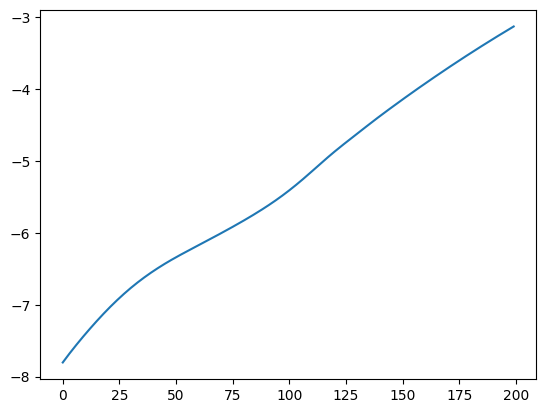

In [78]:
plt.plot(results['A']['static_kan'][1][100]['r2s'])

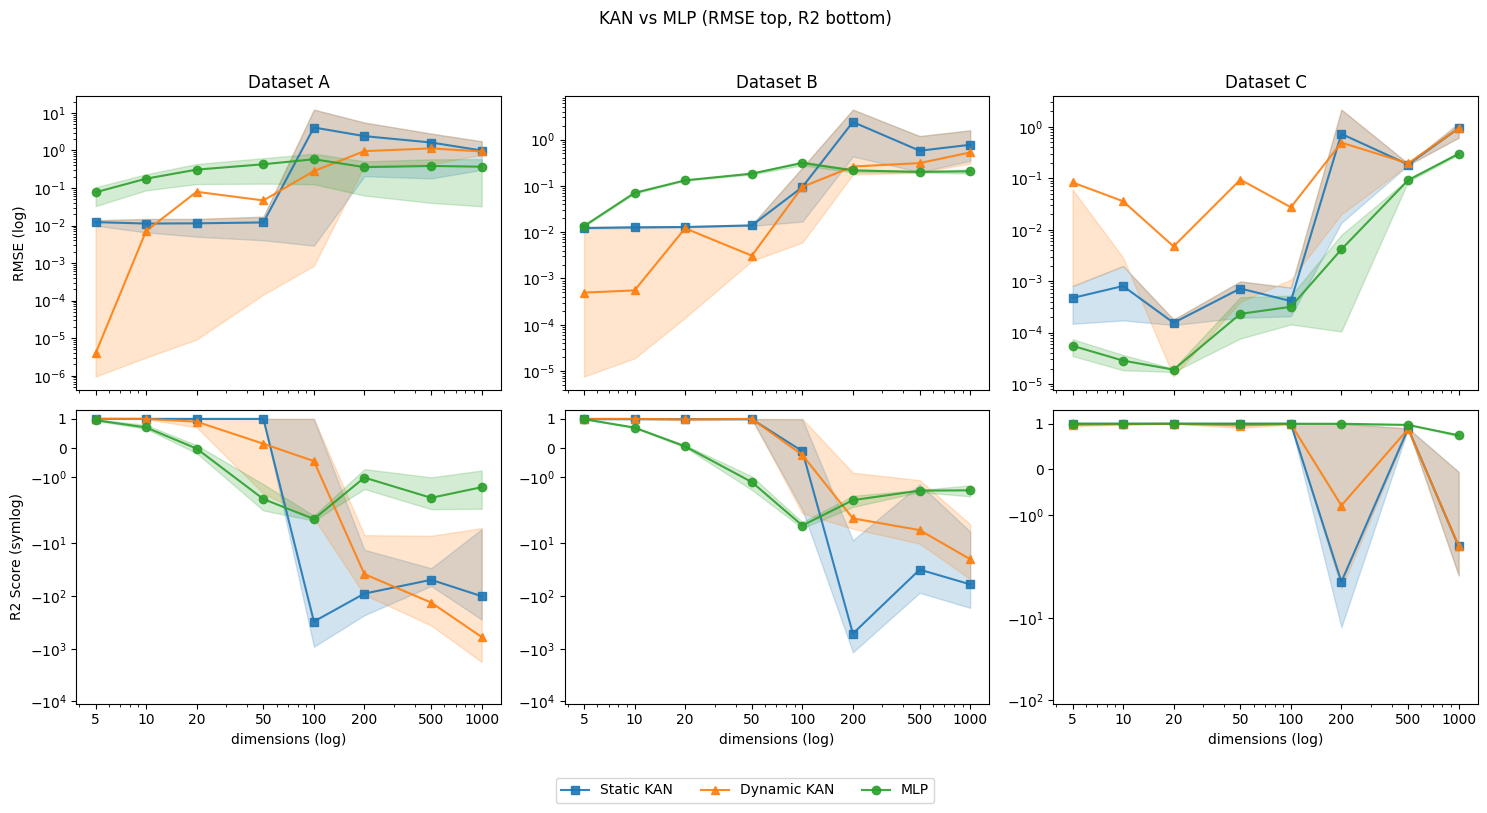

In [56]:
plot_r2s_rmses_all(
    [results['A']['static_kan'], results['B']['static_kan'], results['C']['static_kan']],
    [results['A']['dyn_kan'], results['B']['dyn_kan'], results['C']['dyn_kan']],
    [results['A']['mlp'], results['B']['mlp'], results['C']['mlp']],
    dimensions,
    seeds,
    ['A', 'B', 'C'],
    plot_mlp=True,
    cutoff=3
)


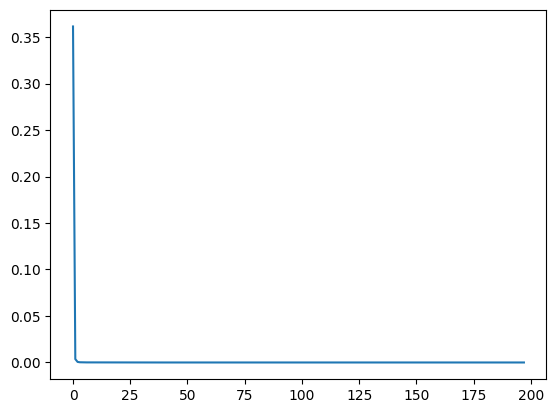

In [62]:
plt.plot(results['C']['dyn_kan'][0][5]['train_losses'])
# plt.plot(results['C']['dyn_kan'][0][5]['rmses'])

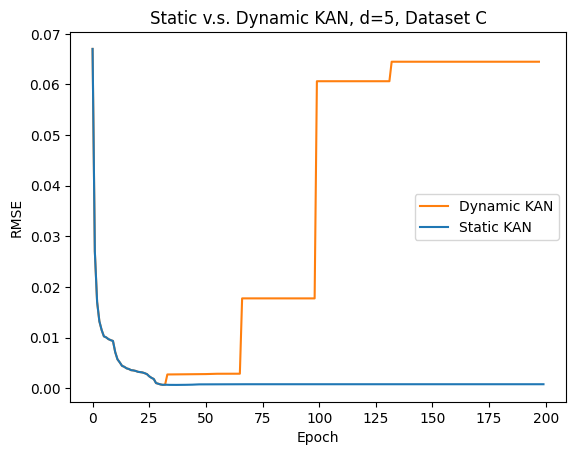

In [75]:
plt.plot(results['C']['dyn_kan'][0][5]['rmses'], label='Dynamic KAN', color='tab:orange')
plt.plot(results['C']['static_kan'][0][5]['rmses'], label='Static KAN', color='tab:blue')
plt.title('Static v.s. Dynamic KAN, d=5, Dataset C')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()
plt.savefig("3-epoch-comparison-C.png", bbox_inches='tight', dpi=300)

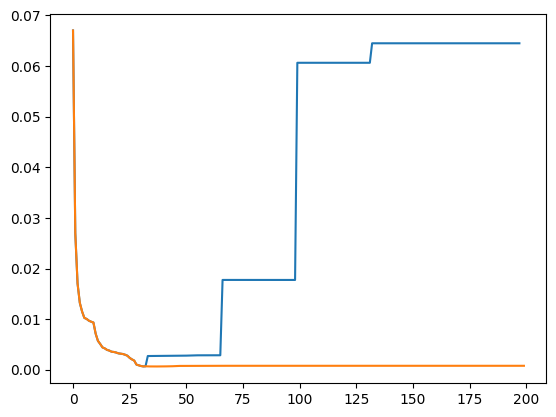

In [67]:
plt.plot(results['C']['dyn_kan'][0][5]['rmses'])
plt.plot(results['C']['static_kan'][0][5]['rmses'])

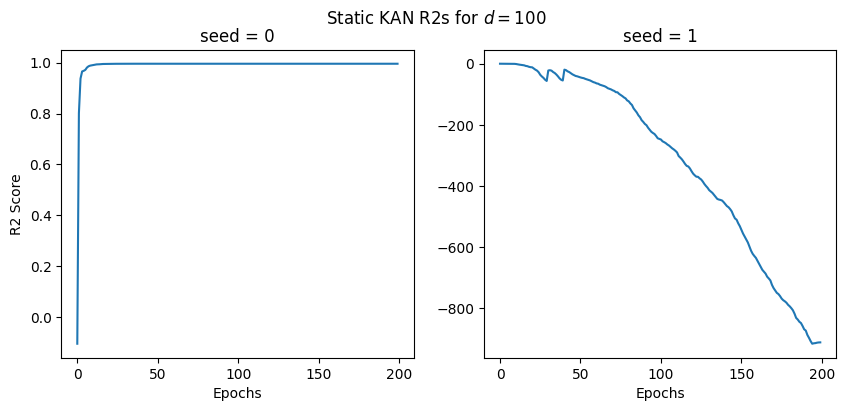

In [59]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4), sharex='col')
ax0.plot(results['A']['static_kan'][0][100]['r2s'])
ax0.set_title('seed = 0')
ax0.set_xlabel('Epochs')
ax0.set_ylabel('R2 Score')

ax1.plot(results['A']['static_kan'][1][100]['r2s'])
ax1.set_title('seed = 1')
ax1.set_xlabel('Epochs')
fig.suptitle('Static KAN R2s for $d=100$')
plt.savefig("3-static-kan-r2s-d100.png", bbox_inches='tight', dpi=300)
plt.show()

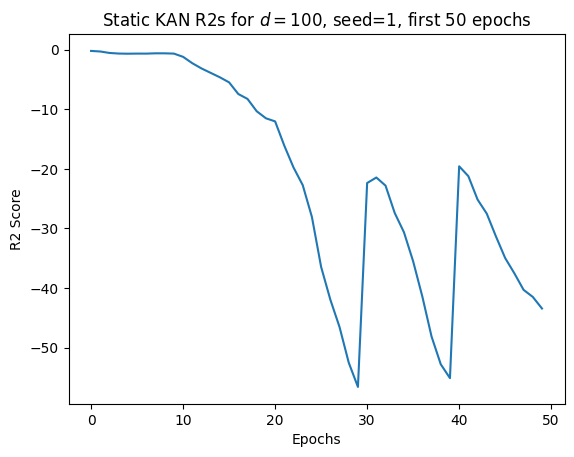

In [58]:
plt.plot(results['A']['static_kan'][1][100]['r2s'][:50])
plt.title('Static KAN R2s for $d=100$, seed=1, first 50 epochs')
plt.xlabel('Epochs')
plt.ylabel('R2 Score')
plt.savefig("3-static-kan-r2s-zoom.png", bbox_inches='tight', dpi=300)
plt.show()

In [63]:
print(results['A']['static_kan'][1][100]['rmses'])

[0.44300442934036255, 0.460223525762558, 0.5017215609550476, 0.5179274678230286, 0.5218803882598877, 0.5190685391426086, 0.5195974707603455, 0.5117635130882263, 0.5120413899421692, 0.5191428661346436, 0.5984914898872375, 0.7298630475997925, 0.8222594857215881, 0.8929768800735474, 0.9584029912948608, 1.0280930995941162, 1.1728227138519287, 1.2287393808364868, 1.3592123985290527, 1.4282188415527344, 1.4577596187591553, 1.6704483032226562, 1.8402780294418335, 1.9669432640075684, 2.1777560710906982, 2.4714198112487793, 2.6463468074798584, 2.7843871116638184, 2.9541163444519043, 3.0646491050720215, 1.9522876739501953, 1.9133124351501465, 1.9705538749694824, 2.152561902999878, 2.2712950706481934, 2.4402832984924316, 2.630664825439453, 2.830759286880493, 2.96173095703125, 3.0252232551574707, 1.8313243389129639, 1.9038043022155762, 2.064908504486084, 2.15639328956604, 2.296738862991333, 2.4218637943267822, 2.5066025257110596, 2.595337152481079, 2.63216233253479, 2.6918396949768066, 2.740553379

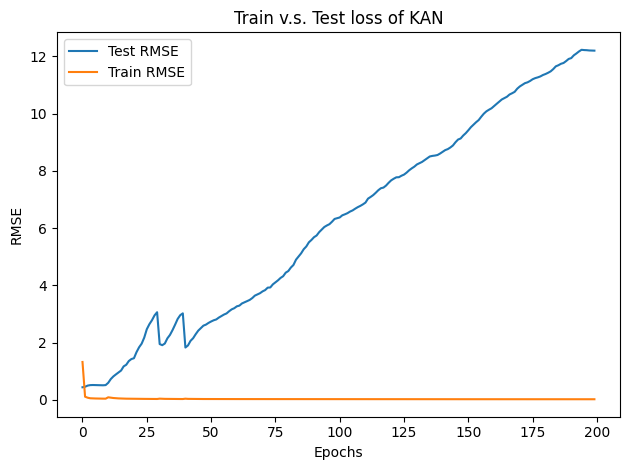

In [65]:
# Extract the loss arrays from your results dictionary
# Note: Since the plot shows RMSE, we use the original arrays directly 
# assuming they store the history over epochs.
train_rmse_history = results['A']['static_kan'][1][100]['train_losses']
test_rmse_history = results['A']['static_kan'][1][100]['rmses']

# Create the plot
plt.figure(figsize=(6.4, 4.8)) # Standard default matplotlib size

# Plot Test RMSE first so it sits behind/matches the legend order if needed,
# or match the exact visual layout.
plt.plot(test_rmse_history, label='Test RMSE', color='tab:blue')
plt.plot(train_rmse_history, label='Train RMSE', color='tab:orange')

# Add labels and title matching the image
plt.title('Train v.s. Test loss of KAN')
plt.xlabel('Epochs')
plt.ylabel('RMSE')

# Configure legend and layout
plt.legend(loc='upper left')
plt.tight_layout()

plt.savefig("3-static-kan-rmse-history.png", bbox_inches='tight', dpi=300)
# Display the plot
plt.show()

In [68]:
print(torch.max(results['A']['static_kan'][1][100]['preds']))

tensor(2.9625)


In [70]:
print(torch.max(results['A']['static_kan'][1][100]['preds']))

tensor(2.9625)


In [ ]:
rmses = []
r2s = []
train_losses = []
early_stopping = False
stopped_at_n = None

dataset_path = os.path.join("datasets", f'seed 1', f'A_dataset_dim100_seed1.pt')
dataset = torch.load(dataset_path, map_location='cpu')

run_steps = steps
grids = [grids[0]]

for grid in grids:

    if early_stopping:
        break
    width = [100, 1, 1]
    if grid==grids[0]:
        model = KAN(width=width, grid=grid, k=k, seed=1, device=device, auto_save=False)
        model = model.speed()
    else:
        model.save_act = True
        model.get_act(dataset['train_input'])
        model = model.refine(grid)
        model = model.speed()
    criterion = torch.nn.MSELoss()

    optimizer = LBFGS(
            model.parameters(), 
            lr=lr, 
            history_size=10, 
            line_search_fn="strong_wolfe",
            tolerance_grad=1e-32, 
            tolerance_change=1e-32, 
            tolerance_ys=1e-32
        )

    pbar = tqdm(range(run_steps), leave=False, desc=f"Grid={grid}")
    for step in pbar:
        def closure():
            optimizer.zero_grad()
            loss = criterion(model(dataset['train_input']), dataset['train_label'])
            loss.backward()
            return loss

        if step % 5 == 0 and step < 100:
            try:
                model.update_grid_from_samples(dataset['train_input'])
            except Exception:
                pass

        loss = optimizer.step(closure)
        train_losses.append(loss.item())
        with torch.no_grad():
            test_pred = model(dataset['test_input'])
            mse = criterion(test_pred, dataset['test_label'])
            rmse = torch.sqrt(mse).item()
            if torch.isnan(test_pred).any():
                r2 = float('-inf')
            else:
                r2 = r2_score(dataset['test_label'].cpu().numpy(), test_pred.cpu().numpy())

        rmses.append(rmse)
        r2s.append(r2)


with torch.no_grad():
    final_pred = model(dataset['test_input'])
        
results = {
    "rmses": rmses,
    "r2s": r2s,
    "preds": final_pred,
    "test_label": dataset['test_label'],
    "stopped_at_n": stopped_at_n,
    "train_losses": train_losses
}

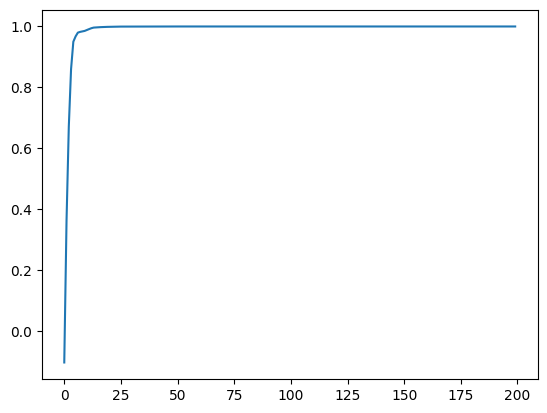

In [7]:
plt.plot(results['r2s'])